In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12


def cfc(signal, time):
    signal = np.asarray(signal)
    time = np.asarray(time)

    dt = np.mean(np.diff(time))
    cfc = 1000  # CFC 1000
    wd = 2 * np.pi * cfc / 0.6 * 1.25
    wa = np.tan(wd * dt / 2.0)
    a0 = wa**2 / (1 + wa**2 + np.sqrt(2) * wa)
    a1 = 2 * a0
    a2 = a0
    b1 = -2 * (wa**2 - 1) / (1 + wa**2 + np.sqrt(2) * wa)
    b2 = (-1 + np.sqrt(2) * wa - wa**2) / (1 + wa**2 + np.sqrt(2) * wa)
    y = np.zeros_like(signal)
    for i in range(2, len(signal)):
        y[i] = (
            a0 * signal[i]
            + a1 * signal[i - 1]
            + a2 * signal[i - 2]
            + b1 * y[i - 1]
            + b2 * y[i - 2]
        )
    x = y.copy()
    y = np.zeros_like(signal)
    for i in range(len(signal) - 3, -1, -1):
        y[i] = a0 * x[i] + a1 * x[i + 1] + a2 * x[i + 2] + b1 * y[i + 1] + b2 * y[i + 2]

    return y

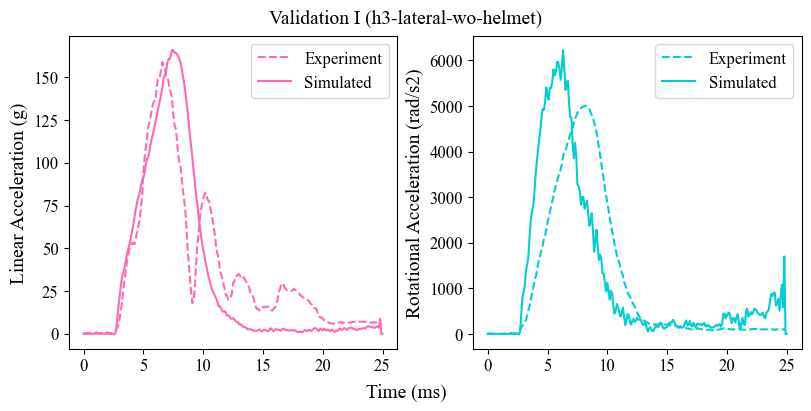

In [2]:
num_pattern = r"[+-]?\d+\.\d+E[+-]?\d+"
time_pattern = r"at time\s*([+-]?\d+\.\d+E[+-]?\d+)"

accels = []
rot_accels = []
current_time = None

with open("nodout") as f:
    nodout = f.readlines()

for i, step in enumerate(nodout):
    time_match = re.search(time_pattern, step)
    if time_match:
        current_time = float(time_match.group(1))
    if "x-disp" in step:
        data_line = nodout[i + 1]
        nums = re.findall(num_pattern, data_line)
        if len(nums) >= 9 and current_time is not None:
            nums = list(map(float, nums))
            accels.append((current_time, *nums[6:9]))
    elif "x-rot" in step:
        data_line = nodout[i + 1]
        nums = re.findall(num_pattern, data_line)
        if len(nums) >= 9 and current_time is not None:
            nums = list(map(float, nums))
            rot_accels.append((current_time, *nums[6:9]))

accel_df = pd.DataFrame(accels, columns=["Time", "X", "Y", "Z"])
rot_accel_df = pd.DataFrame(rot_accels, columns=["Time", "X", "Y", "Z"])
accel_df["Resultant"] = np.linalg.norm(accel_df[["X", "Y", "Z"]].values, axis=1)
rot_accel_df["Resultant"] = np.linalg.norm(rot_accel_df[["X", "Y", "Z"]].values, axis=1)

time = accel_df["Time"]
lit_l = pd.read_csv("linear.csv", header=None)
lit_r = pd.read_csv("rotational.csv", header=None)

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=[8, 4])

ax[0].plot(lit_l[0], lit_l[1] / 50, color="hotpink", label="Experiment", linestyle="--")
ax[1].plot(
    lit_r[0], lit_r[1], color="darkturquoise", label="Experiment", linestyle="--"
)

ax[0].plot(
    time, cfc(accel_df["Resultant"] * 101, time), color="hotpink", label="Simulated"
)
ax[1].plot(
    time,
    cfc(rot_accel_df["Resultant"] * 1000000, time),
    color="darkturquoise",
    label="Simulated",
)

ax[0].legend()
ax[1].legend()
ax[0].set_ylabel("Linear Acceleration (g)", fontsize=14)
ax[1].set_ylabel("Rotational Acceleration (rad/s2)", fontsize=14)
fig.supxlabel("Time (ms)", fontsize=14)
plt.suptitle("Validation I (h3-lateral-wo-helmet)", fontsize=14);